In [ ]:
!pip uninstall mediapipe -y

In [ ]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


Using Colab cache for faster access to the 'indian-classical-mudras-classification' dataset.
Unifying datasets...
Extracting features from unified data...
Processing class: square


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing class: mushti
Processing class: tamrachud
Processing class: shuktund
Processing class: padamkosh
Processing class: katak
Processing class: cock
Processing class: peak
Processing class: ardhpataka
Processing class: mayur
Processing class: swan_wing
Processing class: sarpsheesh
Processing class: lotus_blooming
Processing class: tripataka
Processing class: shikhar
Processing class: hansaasya
Processing class: kartarimukh
Processing class: face_of_a_scissors
Processing class: bhramara
Processing class: aral
Processing class: kangul
Processing class: pataka
Processing class: moon_crescent
Processing class: kapitth
Processing class: mukul
Processing class: sinhamukh
Processing class: mrighasheesh
Processing class: wood_apple
Processing class: soochi
Processing class: chandrakala
Processing class: ardhachandra
Processing class: chatur
Processing class: hamsapaksha
Processing class: swan_face
Processing class: needle
Processing class: trishool
Training model...

🔥 Accuracy: 76.98%



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


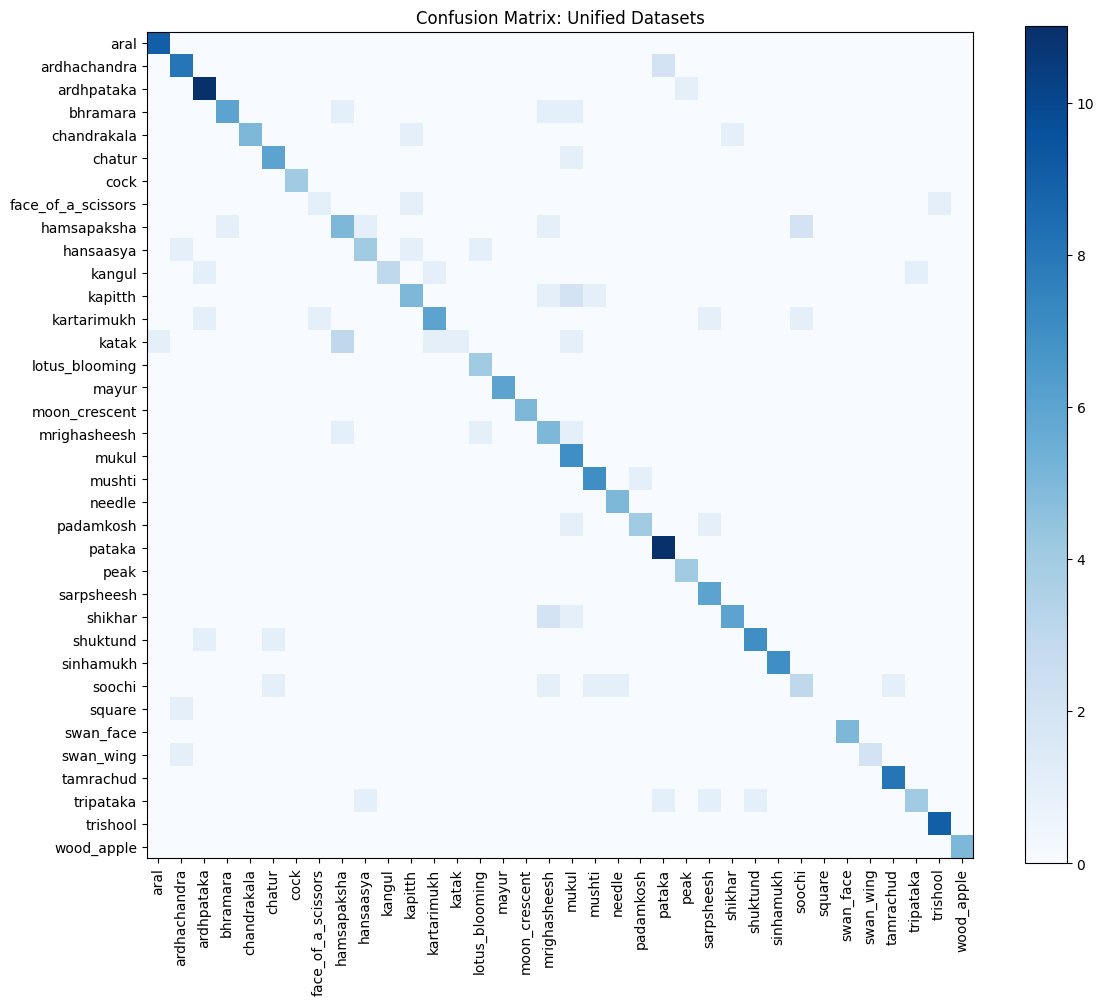

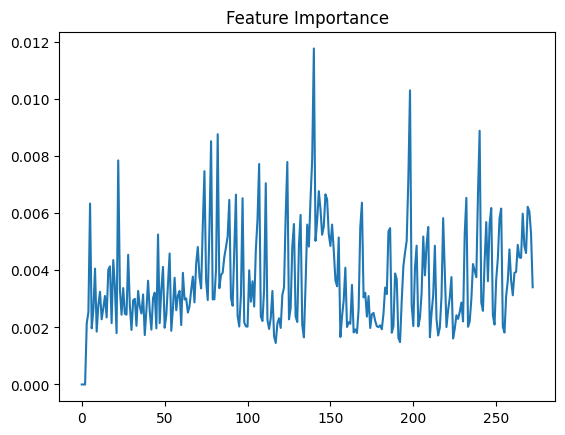

In [ ]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import kagglehub

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ================================
# 1. DOWNLOAD & INFUSE DATA
# ================================
# Download
path1 = kagglehub.dataset_download("ishanishah8/indian-classical-mudras-classification")
path2 = kagglehub.dataset_download("demon2angel/asanyukta-kathak-mudra")

DATA_DIR = "./unified_mudra_data"
DS2_CLASSES = ['Hamsapaksha', 'aral', 'ardhachandra', 'ardhpataka', 'bhramara', 'chandrakala', 'chatur', 'hansaasya', 'kangul', 'kapitth', 'kartarimukh', 'katak', 'mayur', 'mrighasheesh', 'mukul', 'mushti', 'padamkosh', 'pataka', 'sarpsheesh', 'shikhar', 'shuktund', 'sinhamukh', 'soochi', 'tamrachud', 'tripataka', 'trishool']

def infuse_data():
    if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
    os.makedirs(DATA_DIR)

    # Infuse Dataset 1 (Subfolder per class)
    for split in ['train', 'test']:
        split_path = os.path.join(path1, split)
        if not os.path.exists(split_path): continue
        for class_name in os.listdir(split_path):
            cp = os.path.join(split_path, class_name)
            if not os.path.isdir(cp): continue
            target_dir = os.path.join(DATA_DIR, class_name.lower().replace(" ", "_"))
            os.makedirs(target_dir, exist_ok=True)
            for img in os.listdir(cp):
                if img.lower().endswith(('.jpg', '.png', '.jpeg')):
                    shutil.copy2(os.path.join(cp, img), os.path.join(target_dir, f"ds1_{img}"))

    # Infuse Dataset 2 (YOLO Format)
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(path2, split, 'images')
        lbl_dir = os.path.join(path2, split, 'labels')
        if not os.path.exists(img_dir): continue
        for img_name in os.listdir(img_dir):
            lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + ".txt")
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                    if lines:
                        cid = int(lines[0].split()[0])
                        if cid < len(DS2_CLASSES):
                            target_dir = os.path.join(DATA_DIR, DS2_CLASSES[cid].lower())
                            os.makedirs(target_dir, exist_ok=True)
                            shutil.copy2(os.path.join(img_dir, img_name), os.path.join(target_dir, f"ds2_{img_name}"))

print("Unifying datasets...")
infuse_data()

# ================================
# 2. MEDIAPIPE & FEATURE EXTRACTION
# ================================
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1)

def extract_features(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)
    if not results.multi_hand_landmarks: return None

    landmarks = results.multi_hand_landmarks[0].landmark
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    # Normalize (as per your original code)
    coords = coords - coords[0] # Relative to wrist
    max_val = np.max(np.abs(coords))
    if max_val == 0: return None
    coords = coords / max_val

    features = coords.flatten().tolist()
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            dist = np.linalg.norm(coords[i] - coords[j])
            features.append(dist)
    return features

# ================================
# 3. PROCESS UNIFIED DATASET
# ================================
def load_and_extract_all(base_path):
    dataset = []
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        print(f"Processing class: {class_name}")
        for img_name in os.listdir(class_path):
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None: continue

            features = extract_features(img)
            if features is not None:
                dataset.append(features + [class_name])
    return pd.DataFrame(dataset)

print("Extracting features from unified data...")
df = load_and_extract_all(DATA_DIR)

# ================================
# 4. TRAIN / TEST SPLIT & SCALING
# ================================
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. TRAIN & EVALUATE (Original Params)
# ================================
rf = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)

print("Training model...")
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"\n🔥 Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 6. VISUALIZATION
# ================================
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Unified Datasets")
plt.colorbar()
tick_marks = np.arange(len(set(y)))
plt.xticks(tick_marks, sorted(set(y)), rotation=90)
plt.yticks(tick_marks, sorted(set(y)))
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure()
plt.plot(rf.feature_importances_)
plt.title("Feature Importance")
plt.show()